## Exercsie 2: Robot Jacobian & Velocity Control
In this exercise we will implement the robot jacobian and perfrom velocity control of the Franka robot arm.

Before starting the core kinematic exercises, you must prepare your workspace. 
* Import the base robotic library functions from `RealExercise2lib`.
* Ensure you install `opencv-python` to enable the 2D Heads-Up Display (HUD) overlays used in later visualization tasks.

In [14]:
your_name = "Nicolau Vilaclara"
your_vu_id = "liw899"

In [15]:
from RealExercise2lib import *
%pip install opencv-python

In [16]:
import distutils.util
import os
import subprocess
import mediapy as media

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU.')
# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
#%env MUJOCO_GL=egl linux only and mujoco on windows uses wgl by default

try:
  print('Checking that the installation succeeded:')
  import mujoco
  from mujoco import minimize
  from mujoco import rollout
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.')
print('MuJoCo installation successful.')

from IPython.display import clear_output
clear_output()

## Task 1: Implementing the Geometric Jacobian (2 Points)

In this task, you will construct the foundational tool for differential kinematics: the Geometric Jacobian. You will implement the `geometric_jacobian(q, dh_table, joint_types)` function.

* **Objective:** Calculate the $6 \times N$ geometric Jacobian matrix $J_n^0$ for a serial chain.
* **Method:** 
  * Run forward kinematics to extract all intermediate transformation frames and the end-effector position ($d_n^0$).
  * Iterate through each joint to construct the Jacobian columns based on the previous frame's origin and z-axis.
* **Joint Types:** Ensure your logic explicitly handles both Revolute ('R') and Prismatic ('P') joints. For revolute joints, the linear component is determined by the cross product of the z-axis and the vector to the end-effector.

In [17]:
import numpy as np

def geometric_jacobian(q, dh_table, joint_types):
    """Calculates the 6xN geometric Jacobian J_n^0 for any serial chain.
    
    Parameters:
    - q (array-like): Joint vector of length N
    - dh_table (np.ndarray): N x 4 array of [theta_offset, d_offset, a, alpha]
    - joint_types (list): List of strings ('R' for revolute, 'P' for prismatic)
    
    Returns:
    - J_n_0 (np.ndarray): 6xN Geometric Jacobian matrix J_n^0
    """
    N = len(q)
    J_n_0 = np.zeros((6, N))
    
    # 1. Get all intermediate frames from Forward Kinematics
    T_total, all_transforms = forward_kinematics(q, dh_table, joint_types)
    d_n_0 = T_total[:3, 3] # End-effector position (d_n^0)
    
    # 2. Iterate through each joint to construct the Jacobian columns
    for i in range(N):
        # The "previous" frame for joint i is frame i-1
        # If i=0, the previous frame is the global base frame (Identity)
        
        if i == 0:
            T_prev = np.eye(4)
        else:
            T_prev = all_transforms[i-1]

        z = T_prev[:3, 2] #z of prev frame
        o = T_prev[:3, 3] #o of prev frame

        if joint_types[i] == 'R':
            J_n_0[:3, i] = np.cross(z, (d_n_0 - o))
            J_n_0[3:, i] = z

        else:
            J_n_0[:3, i] = z
            
            
    return J_n_0

## Task 1.2: Validating the Jacobian with MuJoCo

To ensure your DH-based Jacobian is correct, you will test it against a professional physics engine, here MuJoCo. You will use the `validate_jacobian` function.

* **Setup:** The function loads a MuJoCo model and updates its state with a test joint configuration (`q_test`).
* **Extraction:** It calls `mujoco.mj_jacSite` to extract MuJoCo's internal linear and angular Jacobians.
* **Comparison:** The function calculates the norm of the difference between your custom geometric Jacobian and MuJoCo's output. An error tolerance of `1e-4` is used to check for a perfect match.

In [18]:
import mujoco

def validate_jacobian(q_test, dh_table, joint_types, model_path, site_name="hand"):
    """Compares the custom DH Jacobian against MuJoCo's built-in solver."""
    
    # 1. Setup MuJoCo
    model = mujoco.MjModel.from_xml_path(model_path)
    data = mujoco.MjData(model)
    
    # Update MuJoCo state
    data.qpos[:len(q_test)] = q_test
    mujoco.mj_kinematics(model, data)
    mujoco.mj_comPos(model, data) # Required before calculating Jacobians
    
    # 2. Extract MuJoCo Jacobian
    body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, site_name)

    jacp = np.zeros((3, model.nv))
    jacr = np.zeros((3, model.nv))

    # Change mj_jacSite to mj_jacBody (or mj_jacBodyCom if you want the center of mass)
    mujoco.mj_jacBody(model, data, jacp, jacr, body_id)
    
    # Combine and slice to match the number of joints we are testing
    J_mujoco = np.vstack((jacp, jacr))[:, :len(q_test)]
    
    # 3. Calculate Student Jacobian
    J_n_0 = geometric_jacobian(q_test, dh_table, joint_types)
    
    # 4. Compare
    error = np.linalg.norm(J_mujoco - J_n_0)
    print(f"Jacobian Difference Norm: {error:.6f}")
    
    if np.allclose(J_mujoco, J_n_0, atol=1e-4):
        print("✅ Jacobian matches MuJoCo perfectly!")
    else:
        print("❌ Jacobian mismatch.")
        
    return J_n_0, J_mujoco

# ==========================================
# TEST CASES USING MUJOCO VALIDATION
# ==========================================
import numpy as np

# Franka Emika Panda DH parameters and joint types
franka_dh = np.array([
    [0.0, 0.333, 0.0, -np.pi / 2],
    [0.0, 0.0, 0.0, np.pi / 2],
    [0.0, 0.316, 0.0825, np.pi / 2],
    [0.0, 0.0, -0.0825, -np.pi / 2],
    [0.0, 0.384, 0.0, np.pi / 2],
    [0.0, 0.0, 0.088, np.pi / 2],
    [0.0, 0.107, 0.0, 0.0],
])
joint_types = ['R'] * 7

# Path to the MuJoCo model
model_path = "mujoco_menagerie/franka_emika_panda/panda.xml"

# ------------------------------------------
# Test Case 1: Standard Neutral Pose
# ------------------------------------------
print("--- Test Case 1: Neutral Pose ---")
q_test_1 = np.array([0.0, -np.pi/4, 0.0, -3*np.pi/4, 0.0, np.pi/2, -np.pi/4])

# Call the validation function
J_student_1, J_mujoco_1 = validate_jacobian(q_test_1, franka_dh, joint_types, model_path)


# ------------------------------------------
# Test Case 2: Arbitrary/Random Pose
# ------------------------------------------
print("\n--- Test Case 2: Arbitrary Pose ---")
q_test_2 = np.array([0.5, 0.3, -0.4, -1.2, 0.8, 1.5, -0.5])

# Call the validation function
J_student_2, J_mujoco_2 = validate_jacobian(q_test_2, franka_dh, joint_types, model_path)

--- Test Case 1: Neutral Pose ---
Jacobian Difference Norm: 0.000000
✅ Jacobian matches MuJoCo perfectly!

--- Test Case 2: Arbitrary Pose ---
Jacobian Difference Norm: 0.000000
✅ Jacobian matches MuJoCo perfectly!


## Task 2: Inverse Jacobian and Trajectory Tracking (2 Points)

In this task, the main objective is to implement the inverse Jacobian. You will use this to make a Franka Emika Panda robot track a continuous Cartesian trajectory.

* **Kinematic Control:** You must convert the desired Cartesian velocities (`xi`) into joint velocities (`q_dot`). To do this, calculate the pseudo-inverse of your geometric Jacobian using the formulas given in the slides and multiply it by the desired velocity vector.
* **Integration:** These computed joint velocities are then integrated over time (`mujoco.mj_integratePos`) to update the robot's physical state.
* **Visualization:** Execute the `run_hud_visualization_demo()` function to see your inverse kinematics in action. The simulation will render a transparent view of the robot alongside a live OpenCV 2D Heads-Up Display (HUD) showing a bar chart of the joint velocities.

Importantly, you need to implement the inverse_jacobian function WITHOUT using `np.linalg.pinv`! You are allowed to use, however, `np.linalg.inv` to compute the standard inverse of a matrix. The parameter `lambda` of the function corresponds to the lambda term for the epsilon term.

In [19]:
def inverse_jacobian(xi, q_curr, franka_dh, joint_types, lambda_val=0.01):
    """
    xi is here the velocity input, i.e. q-dot
    """
    J = geometric_jacobian(q_curr, franka_dh, joint_types)

    #lambda^2 * I keeps J^T J invertible near singlularity
    q_dot = np.linalg.inv(J.T @ J + lambda_val**2 * np.eye(J.shape[1])) @ J.T @ xi
    
    return q_dot

Simulating trajectory and recording dual-view videos...
Done rendering!

--- Video 1: Standard Solid View (3D Spatial Visualization) ---


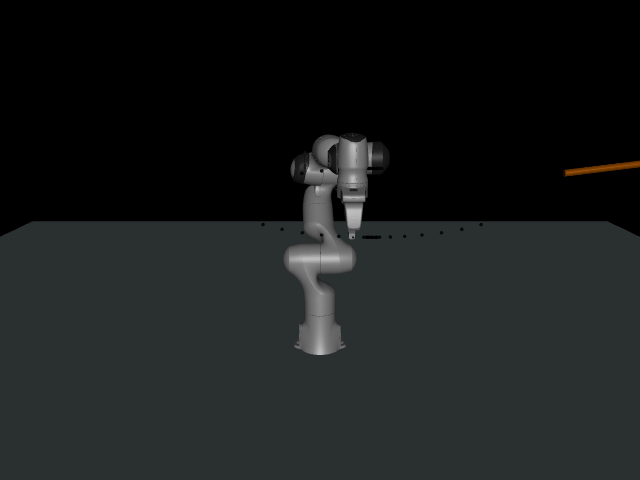


--- Video 2: Transparent View with 2D Telemetry HUD ---


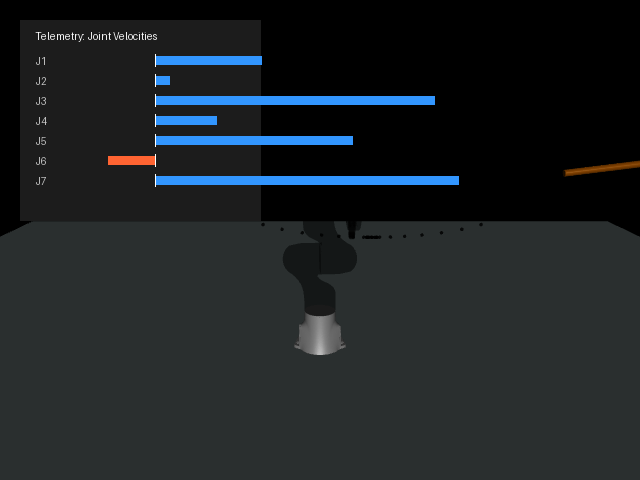


--- Video 2: Transparent View with 2D Telemetry HUD ---


In [20]:
import numpy as np
import mujoco
import mediapy as media
# import cv2  # OpenCV for 2D image overlays
from PIL import Image, ImageDraw
import io
from IPython.display import display, Image as IPImage

def run_hud_visualization_demo():
    # 1. Load Model & Setup Kinematics
    model_path = "mujoco_menagerie/franka_emika_panda/panda.xml"
    try:
        model = mujoco.MjModel.from_xml_path(model_path)
        data = mujoco.MjData(model)
    except Exception as e:
        print(f"Failed to load MuJoCo model: {e}")
        return

    franka_dh = np.array([
        [0.0, 0.333, 0.0, -np.pi / 2],
        [0.0, 0.0, 0.0, np.pi / 2],
        [0.0, 0.316, 0.0825, np.pi / 2],
        [0.0, 0.0, -0.0825, -np.pi / 2],
        [0.0, 0.384, 0.0, np.pi / 2],
        [0.0, 0.0, 0.088, np.pi / 2],
        [0.0, 0.107, 0.0, 0.0],
    ])
    joint_types = ['R'] * 7

    q_init = np.array([0.0, -np.pi/4, 0.0, -3*np.pi/4, 0.0, np.pi/2, -np.pi/4])
    data.qpos[:7] = q_init
    mujoco.mj_kinematics(model, data)

    T_start, _ = forward_kinematics(q_init, franka_dh, joint_types)
    center = T_start[:3, 3] + np.array([0.0, 0.15, 0.0])  
    
    a, b, k = 0.40, 0.10, 0.6
    period = 4.0                                         
    fps = 30
    dt = 1.0 / fps
    total_time = 10.0
    num_steps = int(total_time * fps)

    R_target = T_start[:3, :3]
    Kp_pos = 5.0
    Kp_ori = 5.0

    path_points = []
    for i in range(60): 
        t_pt = i * (period / 60)
        phi_pt = 2 * np.pi * t_pt / period
        theta_pt = phi_pt + k * np.sin(2 * phi_pt)
        pt = center + np.array([0.0, a * np.cos(theta_pt), b * np.sin(theta_pt)])
        path_points.append(pt)

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, cam)
    cam.distance = 2.0
    cam.azimuth = 180.0
    cam.elevation = -15.0
    cam.lookat[:] = [0.0, 0.0, 0.4]

    opt_solid = mujoco.MjvOption()
    opt_transparent = mujoco.MjvOption()
    opt_transparent.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

    frames_solid = []
    frames_transparent = []

    # --- 2D HUD Drawing Function ---
    # --- 2D HUD Drawing Function (Pillow Version) ---
    def draw_hud(frame, q_dot):
        """Draws a live bar chart of joint velocities onto the RGB image using Pillow."""
        # Convert MuJoCo RGB numpy array to a Pillow RGBA image
        img = Image.fromarray(frame).convert("RGBA")
        
        # Create a transparent overlay for drawing
        overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        
        hud_w, hud_h = 240, 200
        hud_x, hud_y = 20, 20
        
        # Draw dark semi-transparent background: (R, G, B, Alpha)
        draw.rectangle([hud_x, hud_y, hud_x + hud_w, hud_y + hud_h], 
                       fill=(40, 40, 40, int(255 * 0.7)))
        
        # Draw Title
        draw.text((hud_x + 15, hud_y + 10), "Telemetry: Joint Velocities", 
                  fill=(255, 255, 255, 255))
        
        # Draw Bars
        max_v = 1.5 # Scaling factor for the bars
        center_x = hud_x + hud_w // 2 + 15
        
        for i in range(7):
            v = q_dot[i]
            y = hud_y + 40 + i * 20
            
            # Joint Label
            draw.text((hud_x + 15, y - 5), f"J{i+1}", fill=(200, 200, 200, 255))
            
            # Calculate bar width based on velocity
            width = int((v / max_v) * (hud_w // 2 - 30))
            
            # Color: Blue for positive velocity, Orange/Red for negative (R, G, B, Alpha)
            color = (50, 150, 255, 255) if v > 0 else (255, 100, 50, 255)
            
            if width > 0:
                draw.rectangle([center_x, y - 4, center_x + width, y + 4], fill=color)
            elif width < 0:
                draw.rectangle([center_x + width, y - 4, center_x, y + 4], fill=color)
                
            # Draw Center Zero-Line
            draw.line([(center_x, y - 6), (center_x, y + 6)], fill=(255, 255, 255, 255), width=1)
            
        # Composite the overlay onto the main image and convert back to RGB
        combined = Image.alpha_composite(img, overlay).convert("RGB")
        
        # Return as a numpy array for mediapy
        return np.array(combined)

    print("Simulating trajectory and recording dual-view videos...")
    
    with mujoco.Renderer(model, height=480, width=640) as renderer:
        for step in range(num_steps):
            t = step * dt

            q_curr = data.qpos[:7].copy()

            phi = 2 * np.pi * t / period
            phi_dot = 2 * np.pi / period
            theta = phi + k * np.sin(2 * phi)
            theta_dot = phi_dot + k * 2 * phi_dot * np.cos(2 * phi)

            d_target_0 = center + np.array([0.0, a * np.cos(theta), b * np.sin(theta)])
            v_des = np.array([0.0, -a * np.sin(theta) * theta_dot, b * np.cos(theta) * theta_dot])
            w_des = np.zeros(3)

            T_curr, _ = forward_kinematics(q_curr, franka_dh, joint_types)
            d_n_0_curr = T_curr[:3, 3]
            R_curr = T_curr[:3, :3]

            e_p = d_target_0 - d_n_0_curr
            e_o = 0.5 * (np.cross(R_curr[:, 0], R_target[:, 0]) +
                         np.cross(R_curr[:, 1], R_target[:, 1]) +
                         np.cross(R_curr[:, 2], R_target[:, 2]))
            
            x_dot_des = np.hstack((v_des + Kp_pos * e_p, w_des + Kp_ori * e_o))


            q_dot = inverse_jacobian(xi=x_dot_des, q_curr=q_curr, franka_dh=franka_dh, joint_types=joint_types, lambda_val=0.001)

            data.qvel[:7] = q_dot
            mujoco.mj_integratePos(model, data.qpos, data.qvel, dt)
            mujoco.mj_kinematics(model, data)

            # Helper function to inject geoms (Now with a toggle flag)
            def add_custom_geoms(show_joint_3d=True):
                # Background floor
                if renderer.scene.ngeom < renderer.scene.maxgeom:
                    geom = renderer.scene.geoms[renderer.scene.ngeom]
                    mujoco.mjv_initGeom(
                        geom, mujoco.mjtGeom.mjGEOM_PLANE,
                        np.array([2.0, 2.0, 0.1]), np.zeros(3), np.eye(3).flatten(),
                        np.array([0.8, 0.9, 0.9, 1.0], dtype=np.float32)
                    )
                    renderer.scene.ngeom += 1

                # Red Trajectory Points
                for pt in path_points:
                    if renderer.scene.ngeom < renderer.scene.maxgeom:
                        geom = renderer.scene.geoms[renderer.scene.ngeom]
                        mujoco.mjv_initGeom(
                            geom, mujoco.mjtGeom.mjGEOM_SPHERE,
                            np.array([0.005, 0.0, 0.0]), pt, np.eye(3).flatten(),
                            np.array([1.0, 0.0, 0.0, 0.6], dtype=np.float32) 
                        )
                        renderer.scene.ngeom += 1

                # Green Target Sphere
                if renderer.scene.ngeom < renderer.scene.maxgeom:
                    geom = renderer.scene.geoms[renderer.scene.ngeom]
                    mujoco.mjv_initGeom(
                        geom, mujoco.mjtGeom.mjGEOM_SPHERE,
                        np.array([0.025, 0.0, 0.0]), d_target_0, np.eye(3).flatten(),
                        np.array([0.0, 1.0, 0.0, 0.8], dtype=np.float32)
                    )
                    renderer.scene.ngeom += 1

                # Orange Cartesian Velocity Vector
                if renderer.scene.ngeom < renderer.scene.maxgeom:
                    geom = renderer.scene.geoms[renderer.scene.ngeom]
                    pt1 = d_n_0_curr
                    v_scale = 0.5 
                    pt2 = d_n_0_curr + x_dot_des[:3] * v_scale 
                    vec = pt2 - pt1
                    length = np.linalg.norm(vec)
                    
                    if length > 1e-4: 
                        pos = (pt1 + pt2) / 2.0
                        quat = np.zeros(4)
                        mujoco.mju_quatZ2Vec(quat, vec)
                        mat = np.zeros(9)
                        mujoco.mju_quat2Mat(mat, quat)
                        
                        mujoco.mjv_initGeom(
                            geom, mujoco.mjtGeom.mjGEOM_ARROW,
                            np.array([0.01, 0.01, length]), pos, mat,
                            np.array([1.0, 0.5, 0.0, 1.0], dtype=np.float32)
                        )
                        renderer.scene.ngeom += 1


            # --- RENDER PASS 1: Solid Robot + 3D Spin Wheels ---
            renderer.update_scene(data, camera=cam, scene_option=opt_solid)
            add_custom_geoms(show_joint_3d=True)
            frames_solid.append(renderer.render())

            # --- RENDER PASS 2: Transparent Robot + 2D HUD Overlay ---
            renderer.update_scene(data, camera=cam, scene_option=opt_transparent)
            add_custom_geoms(show_joint_3d=False) # Turn off the 3D joint arrows here!
            
            # Extract raw image array, apply HUD graphics, and append
            raw_frame = renderer.render().copy()
            hud_frame = draw_hud(raw_frame, q_dot)
            frames_transparent.append(hud_frame)

    print("Done rendering!")
    
    print("\n--- Video 1: Standard Solid View (3D Spatial Visualization) ---")
    # media.show_video(frames_solid, fps=fps)
    frames = frames_solid
    # 6. Display the resulting video inside the Jupyter notebook cell
    # media.show_video(frames, fps=framerate)
    pil_images = [Image.fromarray(frame) for frame in frames]
        
    # Save frames into an in-memory byte buffer as an animated GIF
    buffer = io.BytesIO()
    pil_images[0].save(
        buffer,
        format='GIF',
        save_all=True,
        append_images=pil_images[1:],
        duration=int(500 / 30), # duration per frame in milliseconds
        loop=0
    )
    buffer.seek(0)
    
    # Display the GIF inside the Jupyter notebook
    display(IPImage(data=buffer.read(), format='gif'))

    print("\n--- Video 2: Transparent View with 2D Telemetry HUD ---")
    # media.show_video(frames_transparent, fps=fps)
    frames = frames_transparent
    # 6. Display the resulting video inside the Jupyter notebook cell
    # media.show_video(frames, fps=framerate)
    pil_images = [Image.fromarray(frame) for frame in frames]
        
    # Save frames into an in-memory byte buffer as an animated GIF
    buffer = io.BytesIO()
    pil_images[0].save(
        buffer,
        format='GIF',
        save_all=True,
        append_images=pil_images[1:],
        duration=int(500 / 30), # duration per frame in milliseconds
        loop=0
    )
    buffer.seek(0)
    
    # Display the GIF inside the Jupyter notebook
    display(IPImage(data=buffer.read(), format='gif'))

    print("\n--- Video 2: Transparent View with 2D Telemetry HUD ---")

if __name__ == "__main__":
    run_hud_visualization_demo()

## Task 3: Singularity Analysis and Damped Least Squares (1 Point)

In this final task, you will explore what happens when the standard pseudo-inverse fails. 

* **The Scenario:** You will command the end-effector straight outward along the X-axis toward the absolute maximum stretch limit of the arm, intentionally inducing a boundary singularity.
* **Manipulability Index:** You will evaluate how close the robot is to a singularity by computing the Yoshikawa Manipulability Index. 

In this Task we will utilize the lambda term you implemented in the previous task! Change the lambda term to cause a singularity behaviour, but make sure that you can still render a video (ie, if the code throws an error due to a singular matrix you did not complete the task successfully!)

Simulating singularity approach...
Singularity simulation finished!


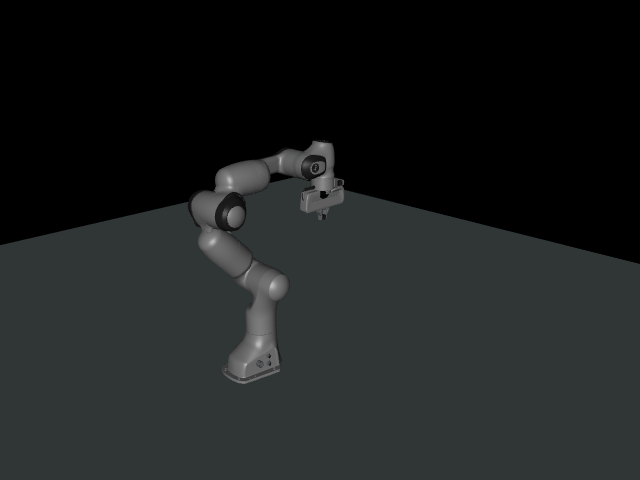

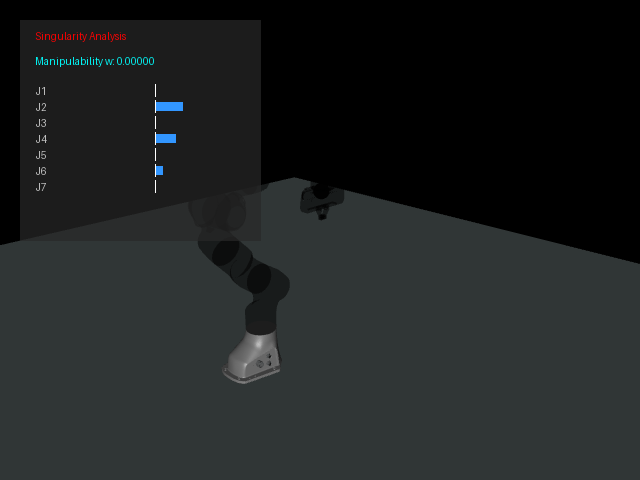

In [21]:
lambda_term = 0.0001

# Do NOT change anything below this comment!

import numpy as np
import mujoco
import mediapy as media

def run_singularity_demo():
    # 1. Load Model & Setup Kinematics
    model_path = "mujoco_menagerie/franka_emika_panda/panda.xml"
    try:
        model = mujoco.MjModel.from_xml_path(model_path)
        data = mujoco.MjData(model)
    except Exception as e:
        print(f"Failed to load MuJoCo model: {e}")
        return

    franka_dh = np.array([
        [0.0, 0.333, 0.0, -np.pi / 2],
        [0.0, 0.0, 0.0, np.pi / 2],
        [0.0, 0.316, 0.0825, np.pi / 2],
        [0.0, 0.0, -0.0825, -np.pi / 2],
        [0.0, 0.384, 0.0, np.pi / 2],
        [0.0, 0.0, 0.088, np.pi / 2],
        [0.0, 0.107, 0.0, 0.0],
    ])
    joint_types = ['R'] * 7

    # Start from a neutral pose
    q_init = np.array([0.0, -np.pi/4, 0.0, -3*np.pi/4, 0.0, np.pi/2, -np.pi/4])
    data.qpos[:7] = q_init
    mujoco.mj_kinematics(model, data)

    T_start, _ = forward_kinematics(q_init, franka_dh, joint_types)
    
    # -------------------------------------------------------------
    # 2. DESIGN A SINGULAR TRAJECTORY
    # Instead of an oval, we send the target straight outward 
    # toward the absolute maximum reach limit of the Franka arm (Boundary Singularity).
    # -------------------------------------------------------------
    start_pos = T_start[:3, 3]
    # Point located at maximum arm stretch along the X-axis
    target_singularity_pos = start_pos + np.array([0.45, 0.0, 0.1]) 

    period = 4.0                                         
    fps = 30
    dt = 1.0 / fps
    total_time = 4.0
    num_steps = int(total_time * fps)

    R_target = T_start[:3, :3]
    Kp_pos = 5.0 # High gain to force it hard against the singularity limit
    Kp_ori = 5.0

    frames_solid = []
    frames_transparent = []

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, cam)
    cam.distance = 2.2
    cam.azimuth = 45.0  # Angled view to see the arm completely stretch out
    cam.elevation = -20.0
    cam.lookat[:] = [0.3, 0.0, 0.4]

    opt_solid = mujoco.MjvOption()
    opt_transparent = mujoco.MjvOption()
    opt_transparent.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

    # Telemetry HUD
    # Telemetry HUD (Pillow Version)
    def draw_hud(frame, q_dot, manipulability):
        # Convert MuJoCo RGB array to Pillow RGBA
        img = Image.fromarray(frame).convert("RGBA")
        overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        
        hud_w, hud_h = 240, 220
        hud_x, hud_y = 20, 20
        
        # Dark semi-transparent background
        draw.rectangle([hud_x, hud_y, hud_x + hud_w, hud_y + hud_h], 
                       fill=(40, 40, 40, int(255 * 0.7)))
        
        # Title text (Turns Red if manipulability drops below 0.01)
        title_color = (255, 0, 0, 255) if manipulability < 0.01 else (255, 255, 255, 255)
        draw.text((hud_x + 15, hud_y + 10), "Singularity Analysis", fill=title_color)
        
        # Display Yoshikawa Manipulability Index (Cyan)
        draw.text((hud_x + 15, hud_y + 35), f"Manipulability w: {manipulability:.5f}", 
                  fill=(0, 255, 255, 255))

        max_v = 2.0 
        center_x = hud_x + hud_w // 2 + 15
        
        for i in range(7):
            v = q_dot[i]
            y = hud_y + 70 + i * 16
            
            # Joint Labels
            draw.text((hud_x + 15, y - 5), f"J{i+1}", fill=(200, 200, 200, 255))
            
            # Bar chart dimensions and color
            width = int((v / max_v) * (hud_w // 2 - 30))
            color = (50, 150, 255, 255) if v > 0 else (255, 100, 50, 255)
            
            if width > 0:
                draw.rectangle([center_x, y - 4, center_x + width, y + 4], fill=color)
            elif width < 0:
                draw.rectangle([center_x + width, y - 4, center_x, y + 4], fill=color)
            
            # Center Zero-Line
            draw.line([(center_x, y - 6), (center_x, y + 6)], fill=(255, 255, 255, 255), width=1)
            
        # Composite and return as numpy array
        combined = Image.alpha_composite(img, overlay).convert("RGB")
        return np.array(combined)

    print("Simulating singularity approach...")

    with mujoco.Renderer(model, height=480, width=640) as renderer:
        for step in range(num_steps):
            t = step * dt
            q_curr = data.qpos[:7].copy()

            # --- Trajectory: Linear push towards the outer boundary limit ---
            # Using a smooth step function to pull the target outward
            alpha_progress = min(1.0, t / (period * 0.6)) # Reaches limit at 60% of runtime
            d_target_0 = start_pos + alpha_progress * (target_singularity_pos - start_pos)
            v_des = np.zeros(3) if alpha_progress >= 1.0 else (target_singularity_pos - start_pos) / (period * 0.6)
            w_des = np.zeros(3)

            # Controller Math
            T_curr, _ = forward_kinematics(q_curr, franka_dh, joint_types)
            d_n_0_curr = T_curr[:3, 3]
            R_curr = T_curr[:3, :3]

            e_p = d_target_0 - d_n_0_curr
            e_o = 0.5 * (np.cross(R_curr[:, 0], R_target[:, 0]) +
                         np.cross(R_curr[:, 1], R_target[:, 1]) +
                         np.cross(R_curr[:, 2], R_target[:, 2]))
            
            x_dot_des = np.hstack((v_des + Kp_pos * e_p, w_des + Kp_ori * e_o))

            q_dot = inverse_jacobian(xi=x_dot_des, q_curr=q_curr, franka_dh=franka_dh, joint_types=joint_types, lambda_val=lambda_term)

            manipulability = 0

            # Integrate state
            data.qvel[:7] = q_dot
            mujoco.mj_integratePos(model, data.qpos, data.qvel, dt)
            mujoco.mj_kinematics(model, data)

            def add_custom_geoms(show_joint_3d=True):
                if renderer.scene.ngeom < renderer.scene.maxgeom:
                    geom = renderer.scene.geoms[renderer.scene.ngeom]
                    mujoco.mjv_initGeom(
                        geom, mujoco.mjtGeom.mjGEOM_PLANE,
                        np.array([2.0, 2.0, 0.1]), np.zeros(3), np.eye(3).flatten(),
                        np.array([0.8, 0.9, 0.9, 1.0], dtype=np.float32)
                    )
                    renderer.scene.ngeom += 1

                # Target marker turns Red when it attempts to push past the singularity boundary
                target_color = np.array([1.0, 0.0, 0.0, 0.9], dtype=np.float32) if alpha_progress >= 1.0 else np.array([0.0, 1.0, 0.0, 0.8], dtype=np.float32)
                if renderer.scene.ngeom < renderer.scene.maxgeom:
                    geom = renderer.scene.geoms[renderer.scene.ngeom]
                    mujoco.mjv_initGeom(
                        geom, mujoco.mjtGeom.mjGEOM_SPHERE,
                        np.array([0.03, 0.0, 0.0]), d_target_0, np.eye(3).flatten(),
                        target_color
                    ) 
                    renderer.scene.ngeom += 1

            # Render Passes
            renderer.update_scene(data, camera=cam, scene_option=opt_solid)
            add_custom_geoms()
            frames_solid.append(renderer.render())

            renderer.update_scene(data, camera=cam, scene_option=opt_transparent)
            add_custom_geoms()
            
            raw_frame = renderer.render().copy()
            hud_frame = draw_hud(raw_frame, q_dot, manipulability)
            frames_transparent.append(hud_frame)

    print("Singularity simulation finished!")
    # media.show_video(frames_solid, fps=fps)
    frames = frames_solid
    # 6. Display the resulting video inside the Jupyter notebook cell
    # media.show_video(frames, fps=framerate)
    pil_images = [Image.fromarray(frame) for frame in frames]
        
    # Save frames into an in-memory byte buffer as an animated GIF
    buffer = io.BytesIO()
    pil_images[0].save(
        buffer,
        format='GIF',
        save_all=True,
        append_images=pil_images[1:],
        duration=int(500 / 30), # duration per frame in milliseconds
        loop=0
    )
    buffer.seek(0)
    
    # Display the GIF inside the Jupyter notebook
    display(IPImage(data=buffer.read(), format='gif'))
    
    # media.show_video(frames_transparent, fps=fps)
    frames = frames_transparent
    # 6. Display the resulting video inside the Jupyter notebook cell
    # media.show_video(frames, fps=framerate)
    pil_images = [Image.fromarray(frame) for frame in frames]
        
    # Save frames into an in-memory byte buffer as an animated GIF
    buffer = io.BytesIO()
    pil_images[0].save(
        buffer,
        format='GIF',
        save_all=True,
        append_images=pil_images[1:],
        duration=int(500 / 30), # duration per frame in milliseconds
        loop=0
    )
    buffer.seek(0)
    
    # Display the GIF inside the Jupyter notebook
    display(IPImage(data=buffer.read(), format='gif'))

if __name__ == "__main__":
    run_singularity_demo()